In [ ]:
import torch
import matplotlib.pyplot as plt

from EX1_1 import LQR   
torch.manual_seed(0)


# Model parameters
# (Choose one set and keep it consistent with Exercise 1.1)

T = 1.0

H = torch.tensor([[0.1, 0.0],
                  [0.0, 0.2]], dtype=torch.float32)

M = torch.eye(2, dtype=torch.float32)
C = torch.eye(2, dtype=torch.float32)
D = torch.eye(2, dtype=torch.float32)
R = torch.eye(2, dtype=torch.float32)

sigma = 0.3 * torch.eye(2, dtype=torch.float32)

x0 = torch.tensor([1.0, 1.0], dtype=torch.float32)


# Create LQR solver from Exercise 1.1

lqr = LQR(H, M, C, D, R, sigma, T)

# Fine time grid for Riccati ODE
t_grid = torch.linspace(0, T, 5000)
lqr.solve_riccati(t_grid)



# Benchmark value from Exercise 1.1
# Need to match the batch-input format of value_function

t0 = torch.tensor([0.0], dtype=torch.float32)            # shape (1,)
x0_batch = x0.unsqueeze(0).unsqueeze(0)                  # shape (1,1,2)

true_value = lqr.value_function(t0, x0_batch).squeeze()

print("Benchmark value function at (t,x)=(0,x0):", true_value.item())



# Explicit Euler Monte Carlo simulation
# under the optimal control from Exercise 1.1

def simulate_LQR(lqr, x0, N, MC):
    """
    Monte Carlo simulation using the explicit Euler discretisation
    of the controlled SDE:
    dX_s = [H X_s + M a(s,X_s)] ds + sigma dW_s
    where a(s,X_s) is the optimal control from Exercise 1.1.
    """

    T = lqr.T
    dt = T / N
    d = len(x0)

    # Initial states: shape (MC, 2)
    X = x0.unsqueeze(0).repeat(MC, 1)

    running_cost = torch.zeros(MC, dtype=torch.float32)

    for n in range(N):
        t = n * dt

        # Match the input format expected by optimal_control
        t_batch = torch.full((MC,), t, dtype=torch.float32)   # shape (MC,)
        X_input = X.unsqueeze(1)                              # shape (MC,1,2)

        # Optimal control from Exercise 1.1
        u = lqr.optimal_control(t_batch, X_input)             # shape (MC,2)

        # Drift term
        drift = X @ lqr.H.T + u @ lqr.M.T

        # Brownian increment
        dW = torch.sqrt(torch.tensor(dt, dtype=torch.float32)) * torch.randn(MC, d)

        # Running cost
        running_cost += (
            torch.sum((X @ lqr.C) * X, dim=1)
            + torch.sum((u @ lqr.D) * u, dim=1)
        ) * dt

        # Explicit Euler update
        X = X + drift * dt + dW @ lqr.sigma.T

    # Terminal cost
    terminal_cost = torch.sum((X @ lqr.R) * X, dim=1)

    cost = running_cost + terminal_cost

    return torch.mean(cost)

Benchmark value function at (t,x)=(0,x0): 2.4747321605682373


Running time-step experiment: N = 1
Running time-step experiment: N = 10
Running time-step experiment: N = 50
Running time-step experiment: N = 100
Running time-step experiment: N = 500
Running time-step experiment: N = 1000
Running time-step experiment: N = 5000


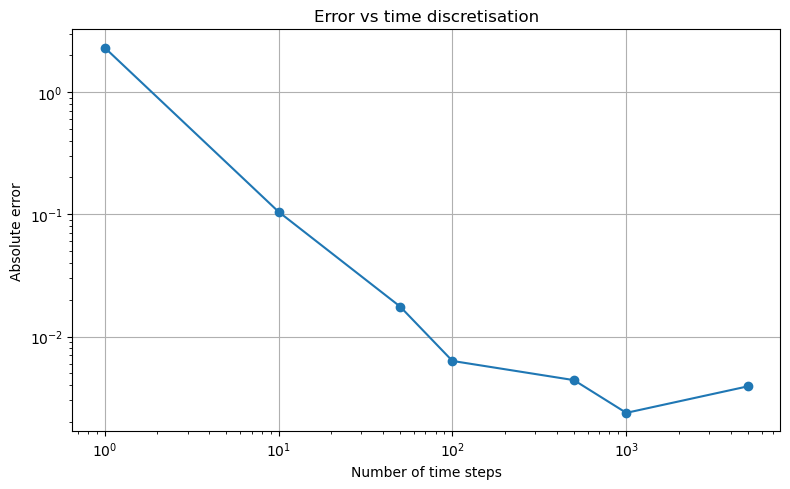

In [ ]:

# Experiment 1:
# Fix MC large, vary number of time steps

MC = 10000
time_steps = [1, 10, 50, 100, 500, 1000, 5000]

errors_time = []

for N in time_steps:
    print(f"Running time-step experiment: N = {N}")
    est = simulate_LQR(lqr, x0, N, MC)
    error = torch.abs(est - true_value)
    errors_time.append(error.item())

plt.figure(figsize=(8, 5))
plt.loglog(time_steps, errors_time, marker='o')
plt.xlabel("Number of time steps")
plt.ylabel("Absolute error")
plt.title("Error vs time discretisation")
plt.grid(True)
plt.tight_layout()
plt.savefig("error_vs_time_discretisation.png", dpi=200)
plt.show()

Running Monte Carlo experiment: MC = 10
Running Monte Carlo experiment: MC = 50
Running Monte Carlo experiment: MC = 100
Running Monte Carlo experiment: MC = 500
Running Monte Carlo experiment: MC = 1000
Running Monte Carlo experiment: MC = 5000
Running Monte Carlo experiment: MC = 10000
Running Monte Carlo experiment: MC = 50000


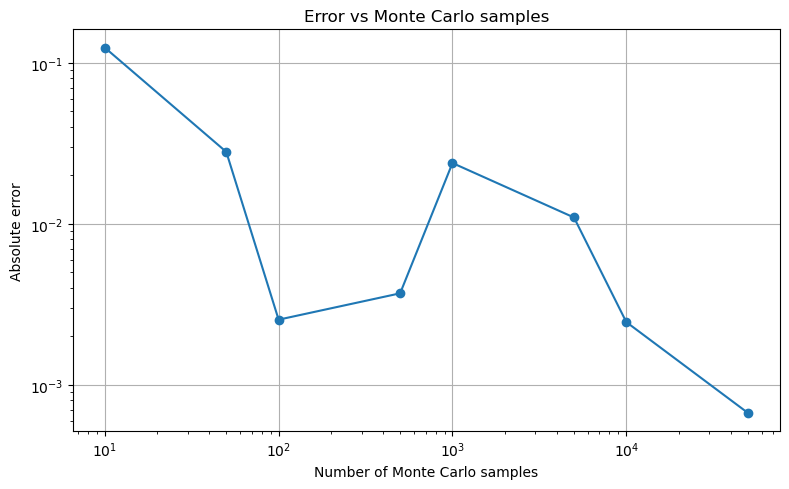

In [ ]:

# Experiment 2:
# Fix N large, vary number of Monte Carlo samples

N = 2000
MC_samples = [10, 50, 100, 500, 1000, 5000, 10000, 50000]

errors_MC = []

for MC in MC_samples:
    print(f"Running Monte Carlo experiment: MC = {MC}")
    est = simulate_LQR(lqr, x0, N, MC)
    error = torch.abs(est - true_value)
    errors_MC.append(error.item())

plt.figure(figsize=(8, 5))
plt.loglog(MC_samples, errors_MC, marker='o')
plt.xlabel("Number of Monte Carlo samples")
plt.ylabel("Absolute error")
plt.title("Error vs Monte Carlo samples")
plt.grid(True)
plt.tight_layout()
plt.savefig("error_vs_monte_carlo_samples.png", dpi=200)
plt.show()